In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert,butter, sosfiltfilt
from scipy.signal.windows import tukey

from tqdm.notebook import tqdm

In [32]:
rf = np.load("intermediate_results/us_arc_inhomog.npy")[..., 0]
# (ntransmissions, ntimesamples, nreceivers, 1)

f0 = 4e6
fs = 4e7
c = 1540

detx, dety = np.load("arc_detector.npy")[:2]

transmit_centre = int(2e-6 * fs)
transmit_width = int(4e-7 * fs)

# Do TGC here?

# Apply IQ demodulation
sos = butter(5, 2 * f0, btype="lowpass", fs=4e7, output="sos")
filtered = 2 * sosfiltfilt(sos, rf * np.exp(-1j * 2 * np.pi * (f0 / fs) * np.arange(rf.shape[1]))[None, :, None], axis=1, padlen=0)

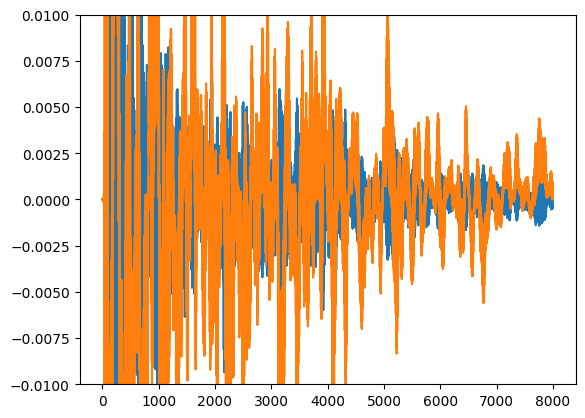

In [33]:
plt.plot(rf[0, :, 0])
plt.plot(np.real(filtered[0, :, 0]) * 2)
plt.ylim([-0.01, 0.01])
plt.show()

In [34]:
# Delay and sum:
nx = 400
lx = 0.04

# Center of pixels
xs = np.linspace(-lx / 2, lx / 2, nx)

X, Y = np.meshgrid(xs, xs)

image = np.zeros((nx, nx), dtype=np.complex128)
# Precompute distances from each detector to all grid points
# detx, dety shape: (n_transmit,) and (n_receive,)
# X, Y shape: (nx, nx)

# Distance from each transmitter to all grid points: (n_transmit, nx, nx)
dist0 = np.sqrt((X[None] - detx[:, None, None])**2 + (Y[None] - dety[:, None, None])**2)

# Distance from each receiver to all grid points: (n_receive, nx, nx)
dist1 = np.sqrt((X[None] - detx[:, None, None])**2 + (Y[None] - dety[:, None, None])**2)

# For each transmit, vectorize over all receives at once
for i_transmit in tqdm(range(rf.shape[0])):
    distance_0 = dist0[i_transmit]  # (nx, nx)
    
    # distance: (n_receive, nx, nx)
    distance = (distance_0[None] + dist1) / (c / fs) + transmit_centre
    index = distance.astype(int)  # (n_receive, nx, nx)
    frac = distance - index        # (n_receive, nx, nx)

    # Gather interpolated samples: filtered shape is (n_transmit, n_samples, n_receive)
    # Rearrange to (n_receive, n_samples) for indexing
    f = filtered[i_transmit]  # (n_samples, n_receive)

    # Index into samples for each receive, each grid point
    r = np.arange(rf.shape[2])  # (n_receive,)
    
    # vals shape: (n_receive, nx, nx)
    vals = (f[index, r[:, None, None]] * (1 - frac) +
            f[index + 1, r[:, None, None]] * frac)
    
    phase = np.exp(1j * distance * 2 * np.pi * f0 / fs)  # (n_receive, nx, nx)
    
    image += (vals * phase).sum(axis=0)  # sum over receives -> (nx, nx)

  0%|          | 0/256 [00:00<?, ?it/s]

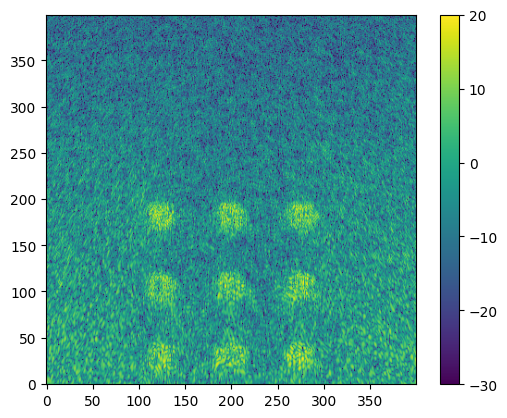

In [40]:
plt.imshow(20 * np.log10(np.abs(image * np.exp(-np.arange(400)/200)[:, None])), origin="lower", clim=(-30, 20))
plt.colorbar()
plt.show()

In [41]:
us_image = 20 * np.log10(np.abs(image * np.exp(-np.arange(400)/200)[:, None]))
us_image = np.clip(us_image, -30, 20)

In [42]:
np.save("output_images/ruct_arc.npy", us_image)